In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorNeuropixelsProjectCache
import tqdm
from scipy.ndimage import gaussian_filter1d
import preprocess_data as ppd
import lstm_module as lstm 
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from captum.attr import IntegratedGradients
import sys
import pandas as pd
import os

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [3]:
output_dir = r"Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022"
output_dir = Path(output_dir)
cache = VisualBehaviorNeuropixelsProjectCache.from_local_cache(cache_dir=output_dir)
session_id = 1044385384 # Arbitrary pick
session = cache.get_ecephys_session(ecephys_session_id=session_id)
behavior_id = session.behavior_session_id
behavior = cache.get_behavior_session(behavior_id)
chan = session.get_channels()
df_path = Path(r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\data') / f'session_{session_id}' / f'session_{session_id}_info.csv'
df      = pd.read_csv(df_path)

c:\Users\SB13FLPC018\miniconda3\envs\torch\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.5.1 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
c:\Users\SB13FLPC018\miniconda3\envs\torch\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.5.0 because version 2.7.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
c:\Users\SB13FLPC018\miniconda3\envs\torch\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-experimental' version 0.2.0 because version 0.5.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
c:\Users\SB13FLPC018\miniconda3\envs\torch\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' v

In [4]:
# change unit_id in df to be the index
df.set_index('unit_id', inplace=True)
# map cluster_id such that 1->2, 2->3, 3->1, 4->4, 5->5 as type int
df['cluster_id'] = df['cluster_id'].map({0:0, 1:2, 2:3, 3:1, 4:4, 5:5}).astype(int)
print(df.head())

           location   probe  firing_rate  dist_from_source  cluster_id
unit_id                                                               
1049374910    VISpm  probeB     8.577549       1305.332525           2
1049374988    VISpm  probeB     0.547925       1365.633553           2
1049373561      POL  probeB    16.918544       2911.231698           0
1049373556      POL  probeB    16.652535       2911.231698           0
1049373138      PoT  probeB    19.336021       3287.960158           0


In [210]:
units = session.get_units()
channels = session.get_channels()
spike_times = session.spike_times
units = units.merge(channels, left_on='peak_channel_id', right_index=True)
units = units[(units.isi_violations < 0.5) &
                                      (units.presence_ratio > 0.9) &
                                      (units.amplitude_cutoff < 0.1) &
                                      (units.firing_rate > 0.1)]

In [ ]:
bin_size = 0.004
start = int(behavior.stimulus_presentations.start_time[behavior.stimulus_presentations.active].iloc[1])
stop  = int(behavior.stimulus_presentations.end_time[behavior.stimulus_presentations.active].iloc[-1])
print(start, stop)

26.994494061509943 3629.4754839934944


In [7]:
spikes_obj = ppd.pre_process_spikes(units, spike_times,bin_size=0.004, sigma=3)
spikes_obj.getSpkMat(start, stop)
spikes_obj.convolve_with_gaussian()
spikes_obj.zscore()

100%|██████████| 741/741 [01:04<00:00, 11.41it/s]


In [49]:
probeC = session.get_lfp(session.probes[session.probes.name == 'probeC'].index[0])
# channel ids for VISp
visp_df = chan.loc[probeC.channel][chan.loc[probeC.channel]['structure_acronym'].str.contains('VISp')]
num_channels = len(visp_df)
lfp_slice = probeC.sel(time=slice(start,stop), channel=visp_df.index)

bands = [(0.5, 4), (4, 8), (8, 12), (12, 25), (25, 50), (50, 100), (100, 200), (200, 400)]
lfp_obj = ppd.pre_process_lfp(lfp_slice.values, 1250)
lfp_obj.filter_lfp(bands)

# resample data from 1250 Hz to 250 Hz to match the spike data
data = lfp_obj.lfpMat[::5,:]
print(data.shape)
print(spikes_obj.spkMat.shape)
# make sure the data is the same length as the spike data
if data.shape[0] > spikes_obj.spkMat.shape[0]:
    data = data[:spikes_obj.spkMat.shape[0],:,:]

(900752, 20, 9)
(900750, 741)


In [51]:
input_size = spikes_obj.spkMat.shape[1]
hidden_size = 50
num_layers = 1
seqlength = 750

In [52]:
# Preprocess data
num_trials = int(data.shape[0] / seqlength)
X = spikes_obj.spkMat[:num_trials * seqlength, :]
lfp = data[:num_trials * seqlength, :,:]

X_reshaped = np.reshape(X, (num_trials, seqlength, X.shape[1]))
lfp_reshaped = np.reshape(lfp, (num_trials, seqlength, lfp.shape[1], lfp.shape[2]))

X_train, X_test, y_train, y_test = train_test_split(X_reshaped, lfp_reshaped, test_size=0.2, random_state=42)

X_train = X_train.reshape(X_train.shape[0] * X_train.shape[1], X_train.shape[2])
X_test = X_test.reshape(X_test.shape[0] * X_test.shape[1], X_test.shape[2])

y_train = y_train.reshape(y_train.shape[0] * y_train.shape[1], y_train.shape[2], y_train.shape[3])
y_test = y_test.reshape(y_test.shape[0] * y_test.shape[1], y_test.shape[2], y_test.shape[3]) 

X_trainT = torch.tensor(X_train).float()
y_trainT = torch.tensor(y_train).float()
X_testT = torch.tensor(X_test).float()
y_testT = torch.tensor(y_test).float()

# remove non-tensor variables to free up memory
del X, lfp, X_reshaped, lfp_reshaped, X_train, X_test, y_train, y_test

print(X_trainT.shape, y_trainT.shape)
print(X_testT.shape, y_testT.shape)

torch.Size([720000, 741]) torch.Size([720000, 20, 9])
torch.Size([180750, 741]) torch.Size([180750, 20, 9])


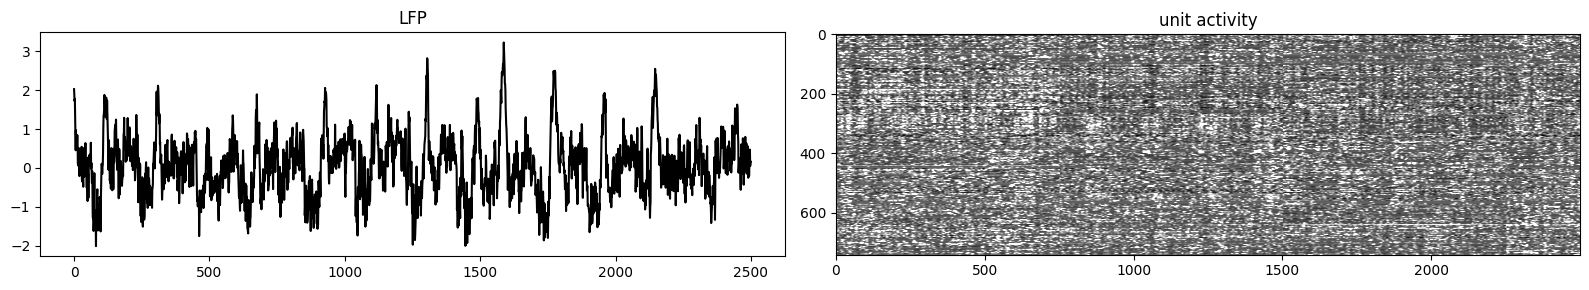

In [55]:
fig, ax = plt.subplots(1,2,figsize=(16, 3))

ax[0].plot(y_trainT.numpy()[:int(10/bin_size),10,0],'k',label='LFP')
# ax[0].plot(stats.zscore(np.mean(X_trainT.cpu().detach().numpy()[:int(10/bin_size),:], axis=1)),'r',label='unit activity')
ax[0].set_title('LFP')

ax[1].imshow(X_trainT.numpy()[:int(10/bin_size),:].T, vmin=-1, vmax=1, cmap='gray')
ax[1].set_title('unit activity')

plt.tight_layout()
plt.show()

In [60]:
criterion = torch.nn.MSELoss()
num_epochs = 15
lossesAll = np.zeros((y_trainT.shape[1], num_epochs, len(bands)+1))

# initialize dictionary to store trained models 
models = {}

for chani in range(num_channels):
    sys.stdout.write('\r' + 'Training model for channel ' + str(chani + 1) + ' out of ' + str(num_channels))
    for bandi in range(len(bands)+1):
        model = lstm.process_model(lstm.LSTMnet(input_size, hidden_size, num_layers), seqlength, criterion, device)
        models[chani, bandi] = model
        losses = model.train(X_trainT, y_trainT[:,chani, bandi].unsqueeze(1) , num_epochs)
        lossesAll[chani,:, bandi] = losses

Finished epoch 15/15hannel 20 out of 20

In [154]:
visp_df['dorsal_ventral_ccf_coordinate'].iloc[0]

1517.0

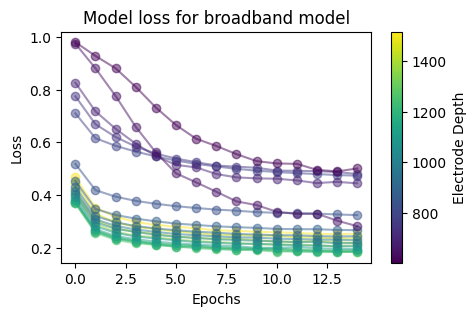

In [155]:
# plot losses for the broadband model for all channels color coded by depth
import matplotlib.cm as cm
import matplotlib.colors as mcolors

fig,ax = plt.subplots(1,1,figsize=(5,3))

norm = mcolors.Normalize(vmin=visp_df['dorsal_ventral_ccf_coordinate'].min(), vmax=visp_df['dorsal_ventral_ccf_coordinate'].max())
cmap = cm.viridis

for chani in range(num_channels):
    color = cmap(norm(visp_df['dorsal_ventral_ccf_coordinate'].iloc[chani]))
    ax.plot(lossesAll[chani, :, 0], 'o-', alpha=0.5, color=color)

ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.set_title('Model loss for broadband model')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Electrode Depth')

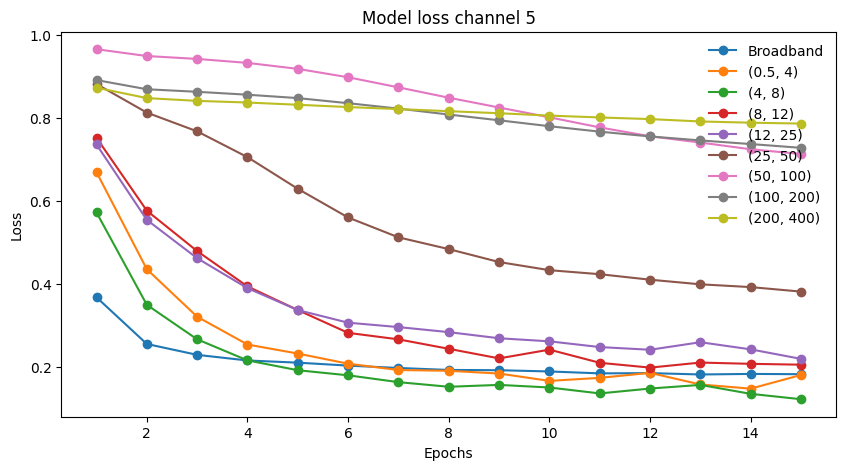

In [144]:
# plot the losses of ch15 for all bands
fig,ax = plt.subplots(1,1,figsize=(10,5))

ax.plot(list(range(1,16)) ,lossesAll[5,:,:],'o-')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.set_title('Model loss channel 5')
# add legend without boxing
ax.legend(['Broadband'] + [str(bands[i]) for i in range(len(bands))], frameon=False, loc='upper right')



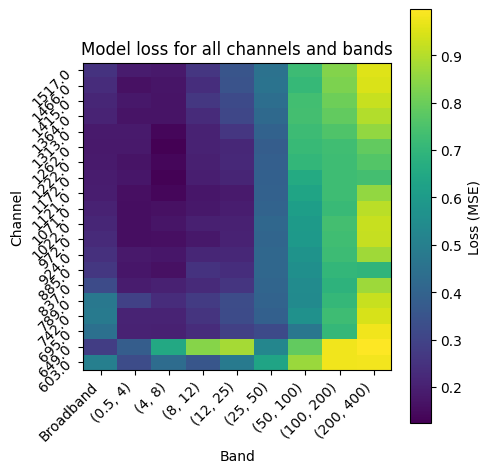

In [157]:
# plot a matrix of losses for the last epoch for all channels and bands
fig,ax = plt.subplots(1,1,figsize=(5,5))
# make the plot square 
cax = ax.imshow(lossesAll[:,-1,:], aspect='equal', cmap='viridis')
ax.set_xlabel('Band')
ax.set_ylabel('Channel')
ax.set_title('Model loss for all channels and bands')
ax.set_yticks(range(num_channels))
ax.set_yticklabels(visp_df.dorsal_ventral_ccf_coordinate, rotation=45)
ax.set_xticks(range(len(bands)+1))
ax.set_xticklabels(['Broadband'] + [str(bands[i]) for i in range(len(bands))], rotation=45, ha='right')
ax.set_aspect(1.0/ax.get_data_ratio(), adjustable='box')
cbar = fig.colorbar(cax)
cbar.set_label('Loss (MSE)')
plt.tight_layout()


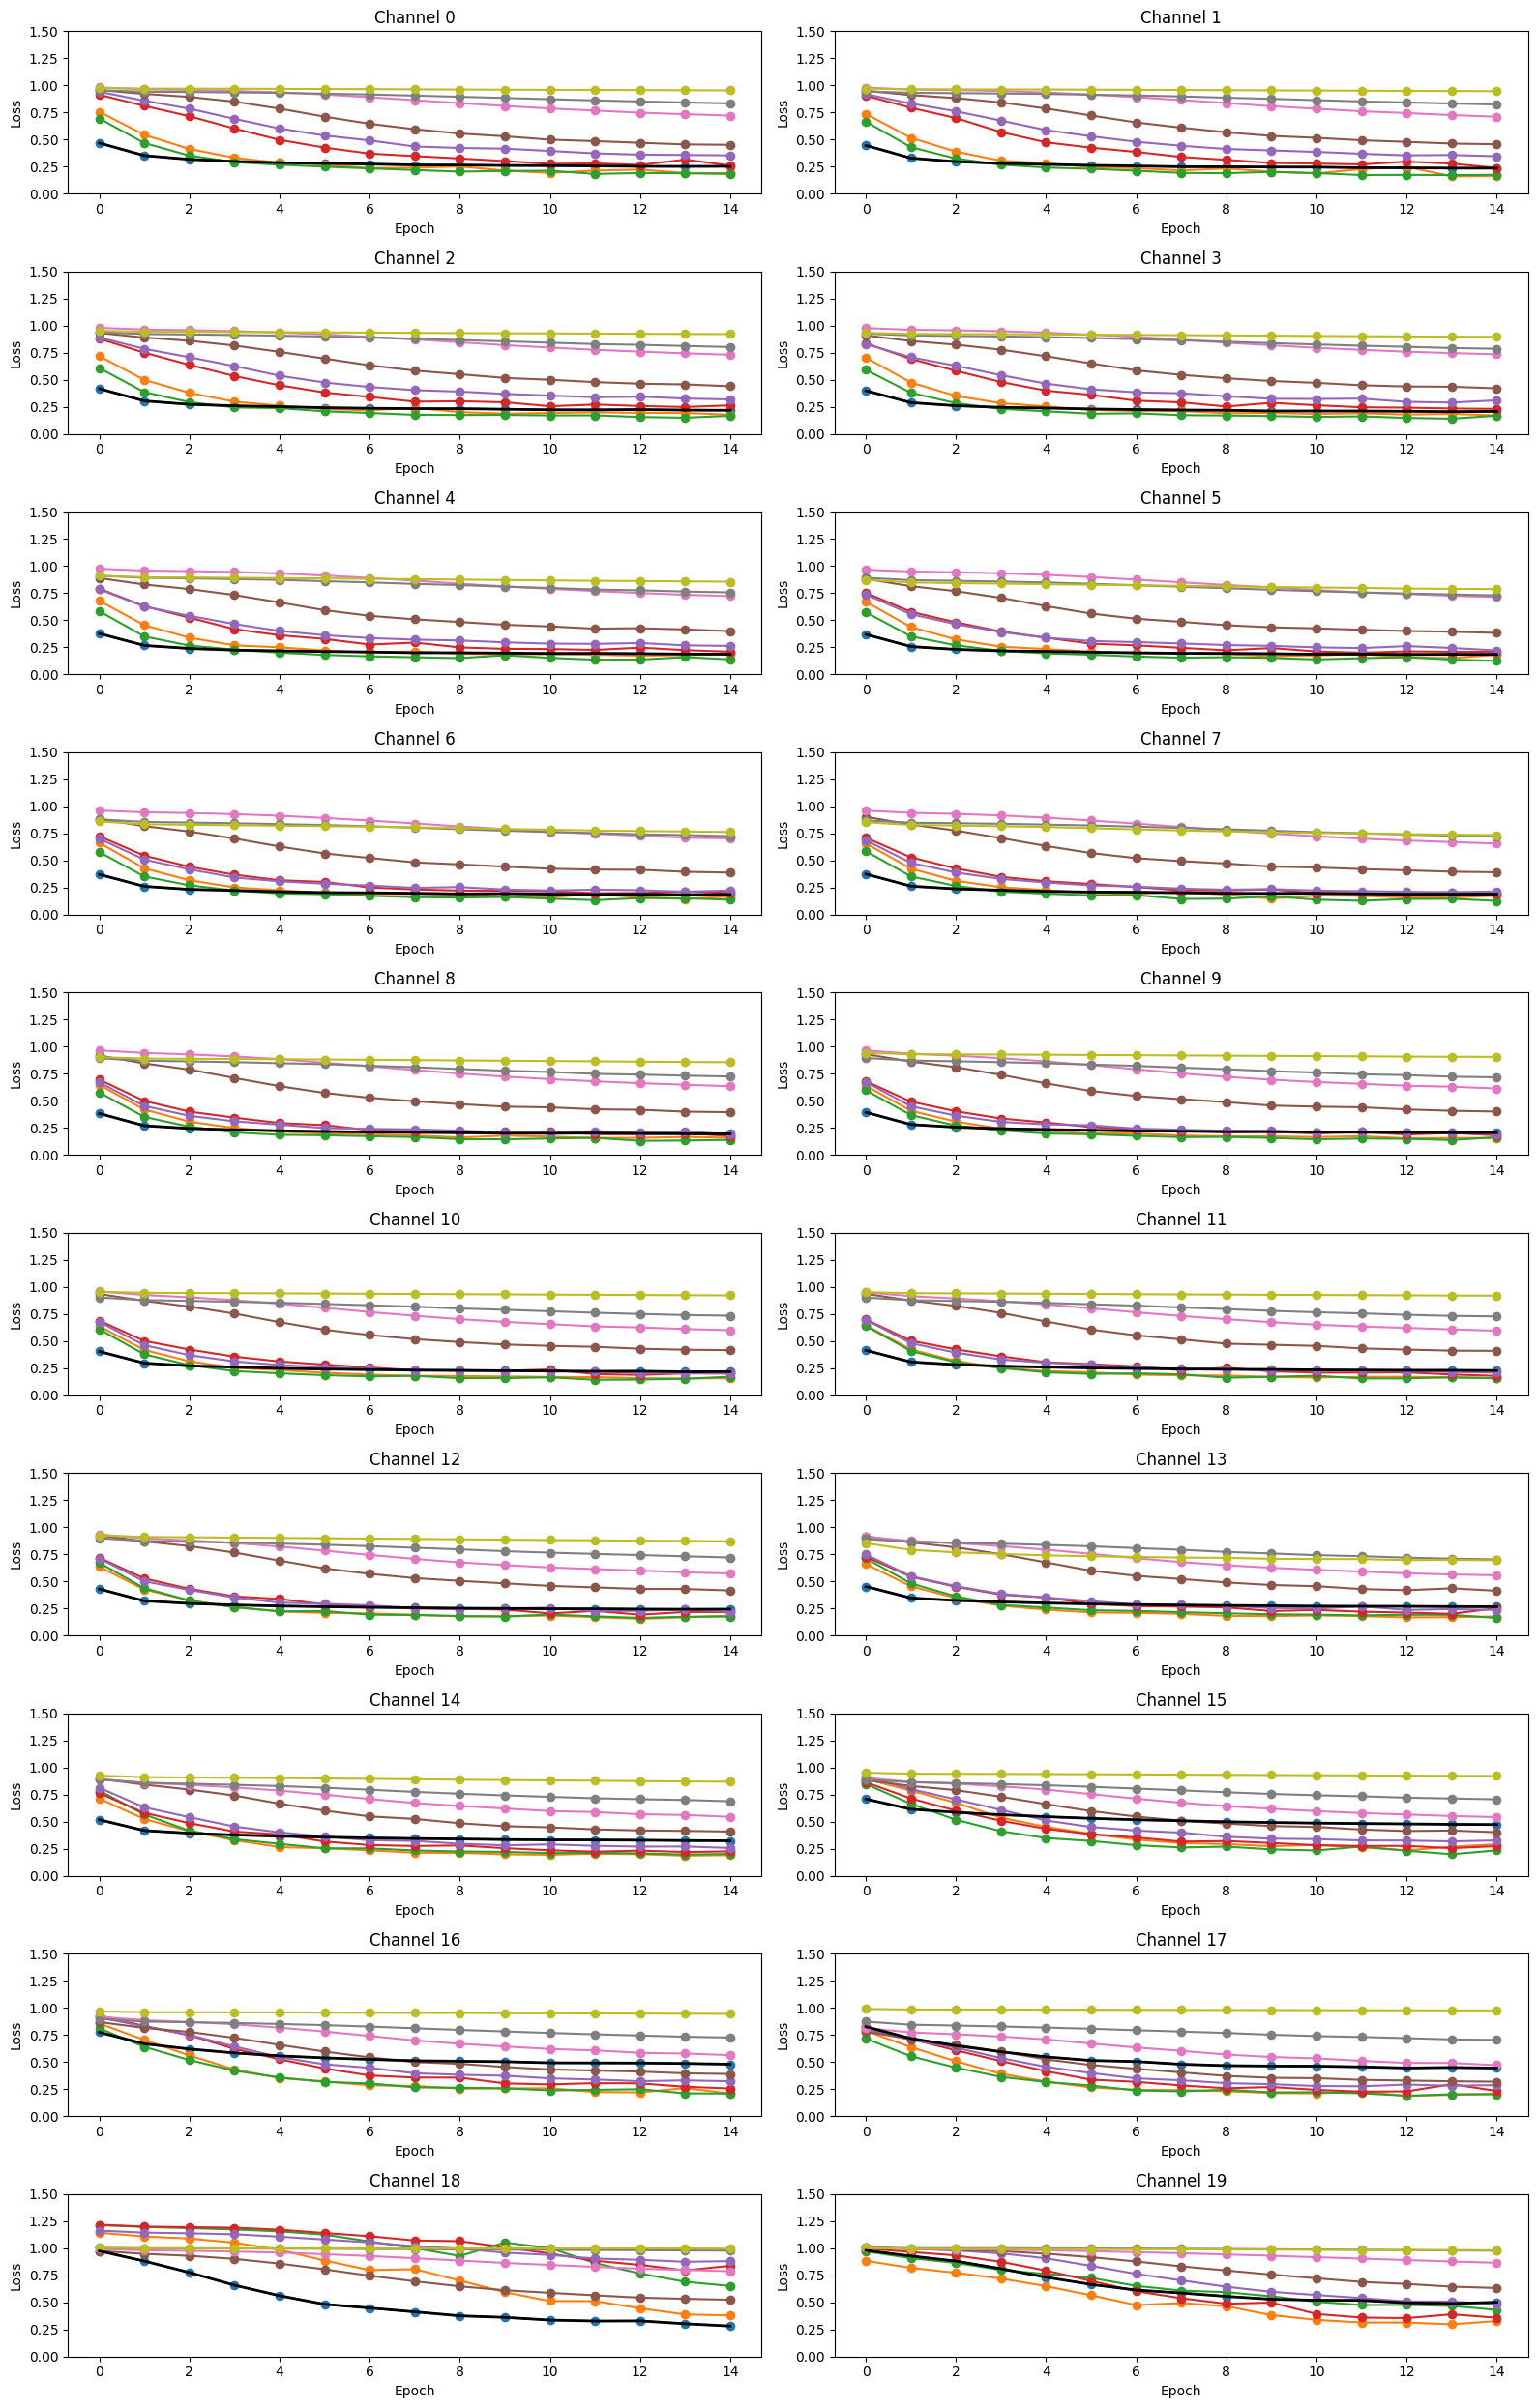

In [76]:
# for each channel, plot the loss for all bands
fig, ax = plt.subplots(int(np.ceil(num_channels/2)),2, figsize=(16, 25))
for chani in range(num_channels):
    ax.flat[chani].plot(lossesAll[chani,:,:,], 'o-')
    ax.flat[chani].plot(lossesAll[chani,:,0], 'k', label='LFP', linewidth=2)
    ax.flat[chani].set_title('Channel ' + str(chani))
    ax.flat[chani].set_xlabel('Epoch')
    ax.flat[chani].set_ylabel('Loss')
    ax.flat[chani].set_ylim([0, 1.5])
    # add space between subplots
    plt.tight_layout()


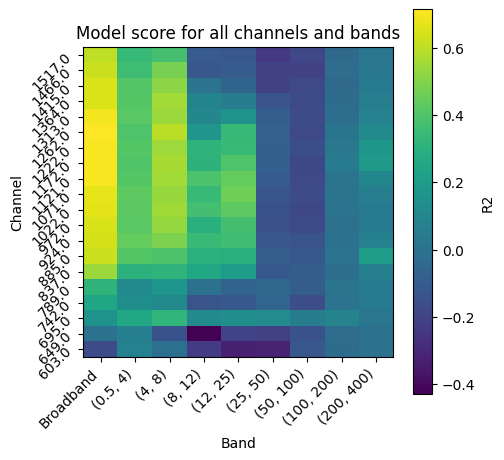

In [158]:
# compute model scores for all channels and bands for the training data and the test data
scoresTrain = np.zeros((num_channels, len(bands)+1))
scoresTest = np.zeros((num_channels, len(bands)+1))

for chani in range(num_channels):
    for bandi in range(len(bands)+1):
        yHat_train = models[chani, bandi].evaluate(X_trainT)
        yHat_test  = models[chani, bandi].evaluate(X_testT)
        r2_train = r2_score(y_trainT[:,chani, bandi].cpu().detach().numpy(), yHat_train)
        r2_test  = r2_score(y_testT[:,chani, bandi].cpu().detach().numpy(), yHat_test)
        scoresTrain[chani, bandi] = r2_train
        scoresTest[chani, bandi] = r2_test
      
        
# plot as a matrix
fig,ax = plt.subplots(1,1,figsize=(5,5))
# make the plot square
cax = ax.imshow(scoresTest, aspect='equal', cmap='viridis')
ax.set_xlabel('Band')
ax.set_ylabel('Channel')
ax.set_title('Model score for all channels and bands')
ax.set_yticks(range(num_channels))
ax.set_yticklabels(visp_df.dorsal_ventral_ccf_coordinate, rotation=45)
ax.set_xticks(range(len(bands)+1))
ax.set_xticklabels(['Broadband'] + [str(bands[i]) for i in range(len(bands))], rotation=45, ha='right')
ax.set_aspect(1.0/ax.get_data_ratio(), adjustable='box')
cbar = fig.colorbar(cax)
cbar.set_label('R2')


In [ ]:
fig, ax = plt.subplots(int(np.ceil(num_channels/2)),2, figsize=(16, 16))

for chani in range(num_channels):
    yHat_test = models[chani].evaluate(X_testT)
    ax.flat[chani].plot(np.linspace(0,5,int(5/bin_size)), y_testT.cpu().detach().numpy()[:int(5/bin_size),chani],'k',label='LFP')
    ax.flat[chani].plot(np.linspace(0,5,int(5/bin_size)), yHat_test[:int(5/bin_size)],'r',label='LSTM')

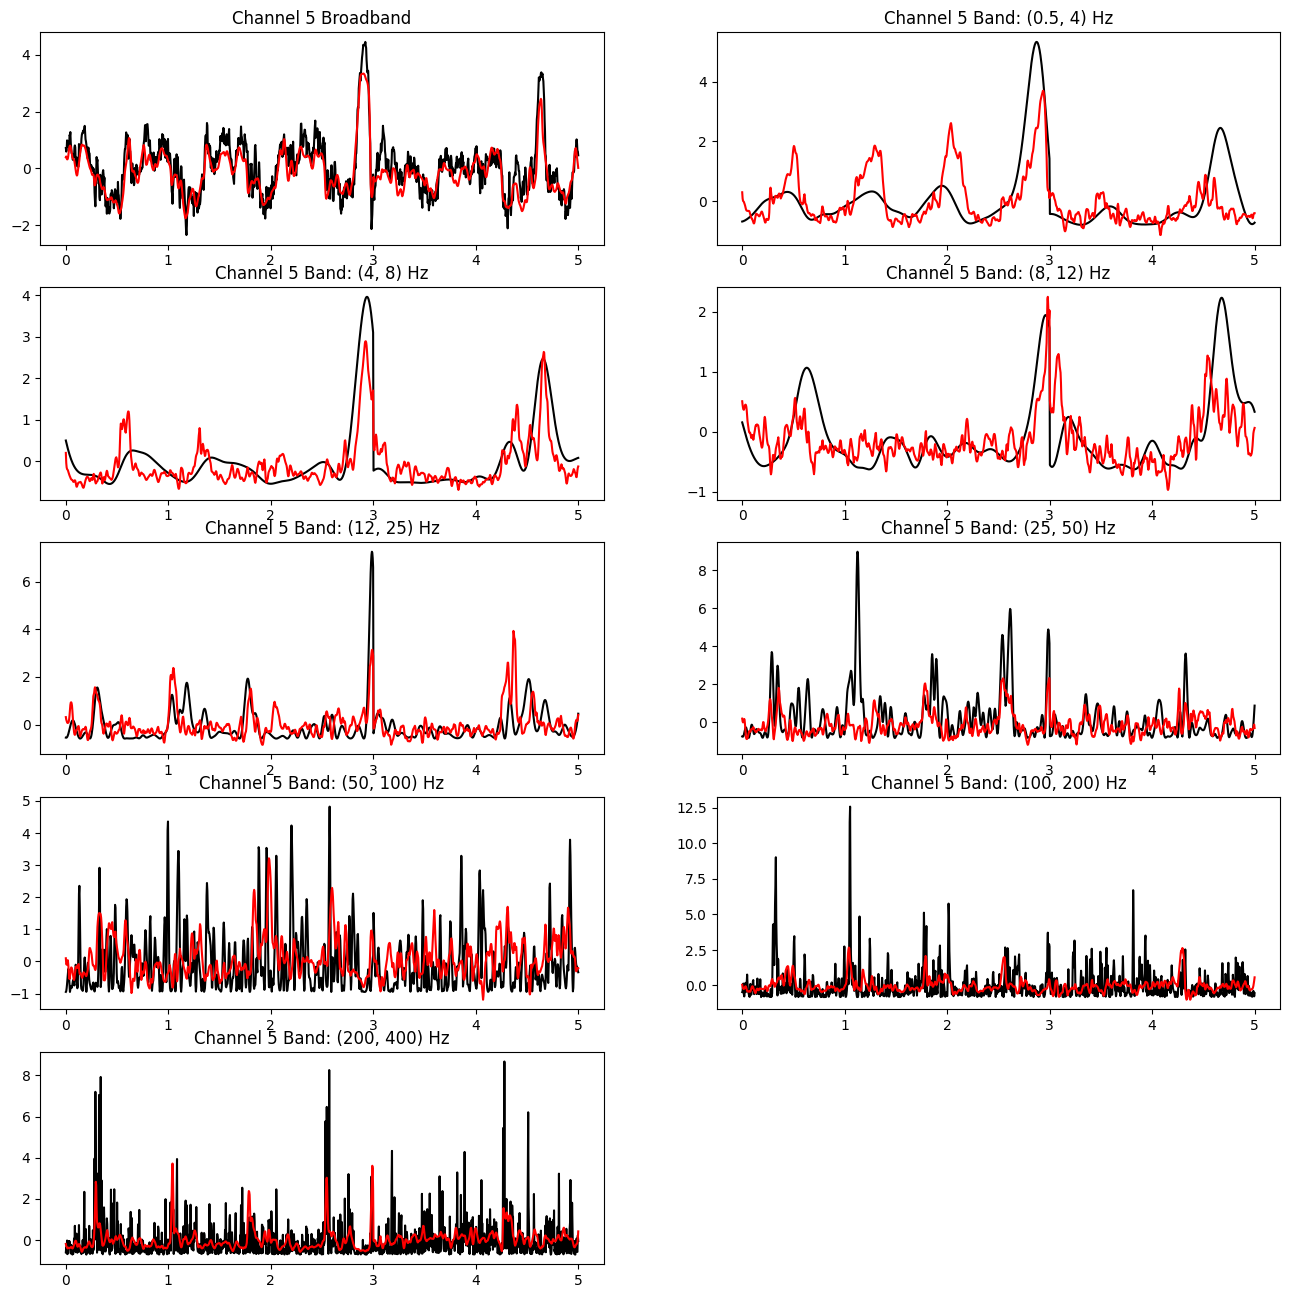

In [137]:
# plot the data and prediction for all bands from a single channel
chani = 5
fig, ax = plt.subplots(int(np.ceil((len(bands)+1)/2)),2, figsize=(16, 16))

for bandi in range(len(bands)+1):
    yHat_test = models[chani, bandi].evaluate(X_testT)
    ax.flat[bandi].plot(np.linspace(0,5,int(5/bin_size)), y_testT.cpu().detach().numpy()[:int(5/bin_size),chani, bandi],'k',label='LFP')
    ax.flat[bandi].plot(np.linspace(0,5,int(5/bin_size)), yHat_test[:int(5/bin_size)],'r',label='LSTM')
    if bandi == 0:
        ax.flat[bandi].set_title('Channel ' + str(chani) + ' Broadband')
    else:
        ax.flat[bandi].set_title('Channel ' + str(chani) + ' Band: ' + str(bands[bandi-1]) + ' Hz')
    
fig.delaxes(ax.flat[-1])

In [136]:
# save the models 
os.makedirs(output_dir / 'models' / str(session_id), exist_ok=True)
for idx in range(len(models.keys())):
    chan = list(models.keys())[idx][0]
    band = list(models.keys())[idx][1]
    filename = output_dir / 'models' / str(session_id) / f'lstm_model_chan{chan}_band{band}.pt'
    torch.save(models[chan, band].model.state_dict(), filename)

In [171]:
# delete large variables to free up memory
del lfp_slice, probeC, data 

In [ ]:
# check if a variable models exists otherwise load it from the saved models
if 'models' not in locals():
    models = {}
    for chani in range(num_channels):
        for bandi in range(len(bands)+1):
            model = lstm.process_model(lstm.LSTMnet(input_size, hidden_size, num_layers), seqlength, criterion, device)
            filename = output_dir / 'models' / str(session_id) / f'lstm_model_chan{chani}_band{bandi}.pt'
            model.model.load_state_dict(torch.load(filename))
            models[chani, bandi] = model    


In [173]:
dur = 720
X_attr = spikes_obj.spkMat[:int(dur/bin_size), :] # first 720 seconds of data
X_attr = torch.tensor(X_attr).float()

# for each channel and band, run the attribution algorithm
for chani in range(num_channels):
    for bandi in range(len(bands)+1):
        sys.stdout.write('running atribution analysis on chan ' + str(chani) + ' band ' + str(bandi) + '.\n')
        mdl = models[chani, bandi].model.train().to('cpu')
        integrated_gradients = IntegratedGradients(mdl)
        filename = output_dir / 'models' / str(session_id) / f'attribution_scores_chan{chani}_band{bandi}.npy' 
        attributions = []
        for i in tqdm.tqdm(range(0,X_attr.shape[0],100)):
            attributions.append(integrated_gradients.attribute(X_attr[i:i+100,:].contiguous(),  target=0,  n_steps=50))
        attributions = torch.cat(attributions)
        attributions = attributions.cpu().detach().numpy().astype('float32')
        np.save(filename, attributions, allow_pickle=True)


running atribution analysis on chan 0 band 0.


100%|██████████| 1800/1800 [05:35<00:00,  5.36it/s]


running atribution analysis on chan 0 band 1.


100%|██████████| 1800/1800 [05:52<00:00,  5.11it/s]


running atribution analysis on chan 0 band 2.


...

100%|██████████| 1800/1800 [05:24<00:00,  5.54it/s]


running atribution analysis on chan 19 band 7.


100%|██████████| 1800/1800 [05:24<00:00,  5.54it/s]


running atribution analysis on chan 19 band 8.


100%|██████████| 1800/1800 [05:25<00:00,  5.53it/s]


In [177]:
# for each channel and band, load the attribution and calculate the mean attribution for each unit
attributions = np.zeros((num_channels, len(bands)+1 , X_attr.shape[1]))
for chani in range(num_channels):
    for bandi in range(len(bands)+1):
        filename = output_dir / 'models' / str(session_id) / f'attribution_scores_chan{chani}_band{bandi}.npy'
        attributions[chani, bandi,:] = np.mean(np.load(filename), axis=0)


In [242]:
# find the index of units in the units dataframe that are also in df dataframe
locs2save = units.index.isin(df.index)

# for each area, calculate the mean attribution across all channels and bands
areas = sorted(df['location'].unique())
attributions_areas = np.zeros((len(areas), len(bands)+1, num_channels))
for areai, area in enumerate(areas):
    ind = ([units['structure_acronym'] == area])[0] & locs2save
    for chani in range(num_channels):
        for bandi in range(len(bands)+1):
            attributions_areas[areai, bandi, chani] = np.mean(attributions[chani, bandi, ind])

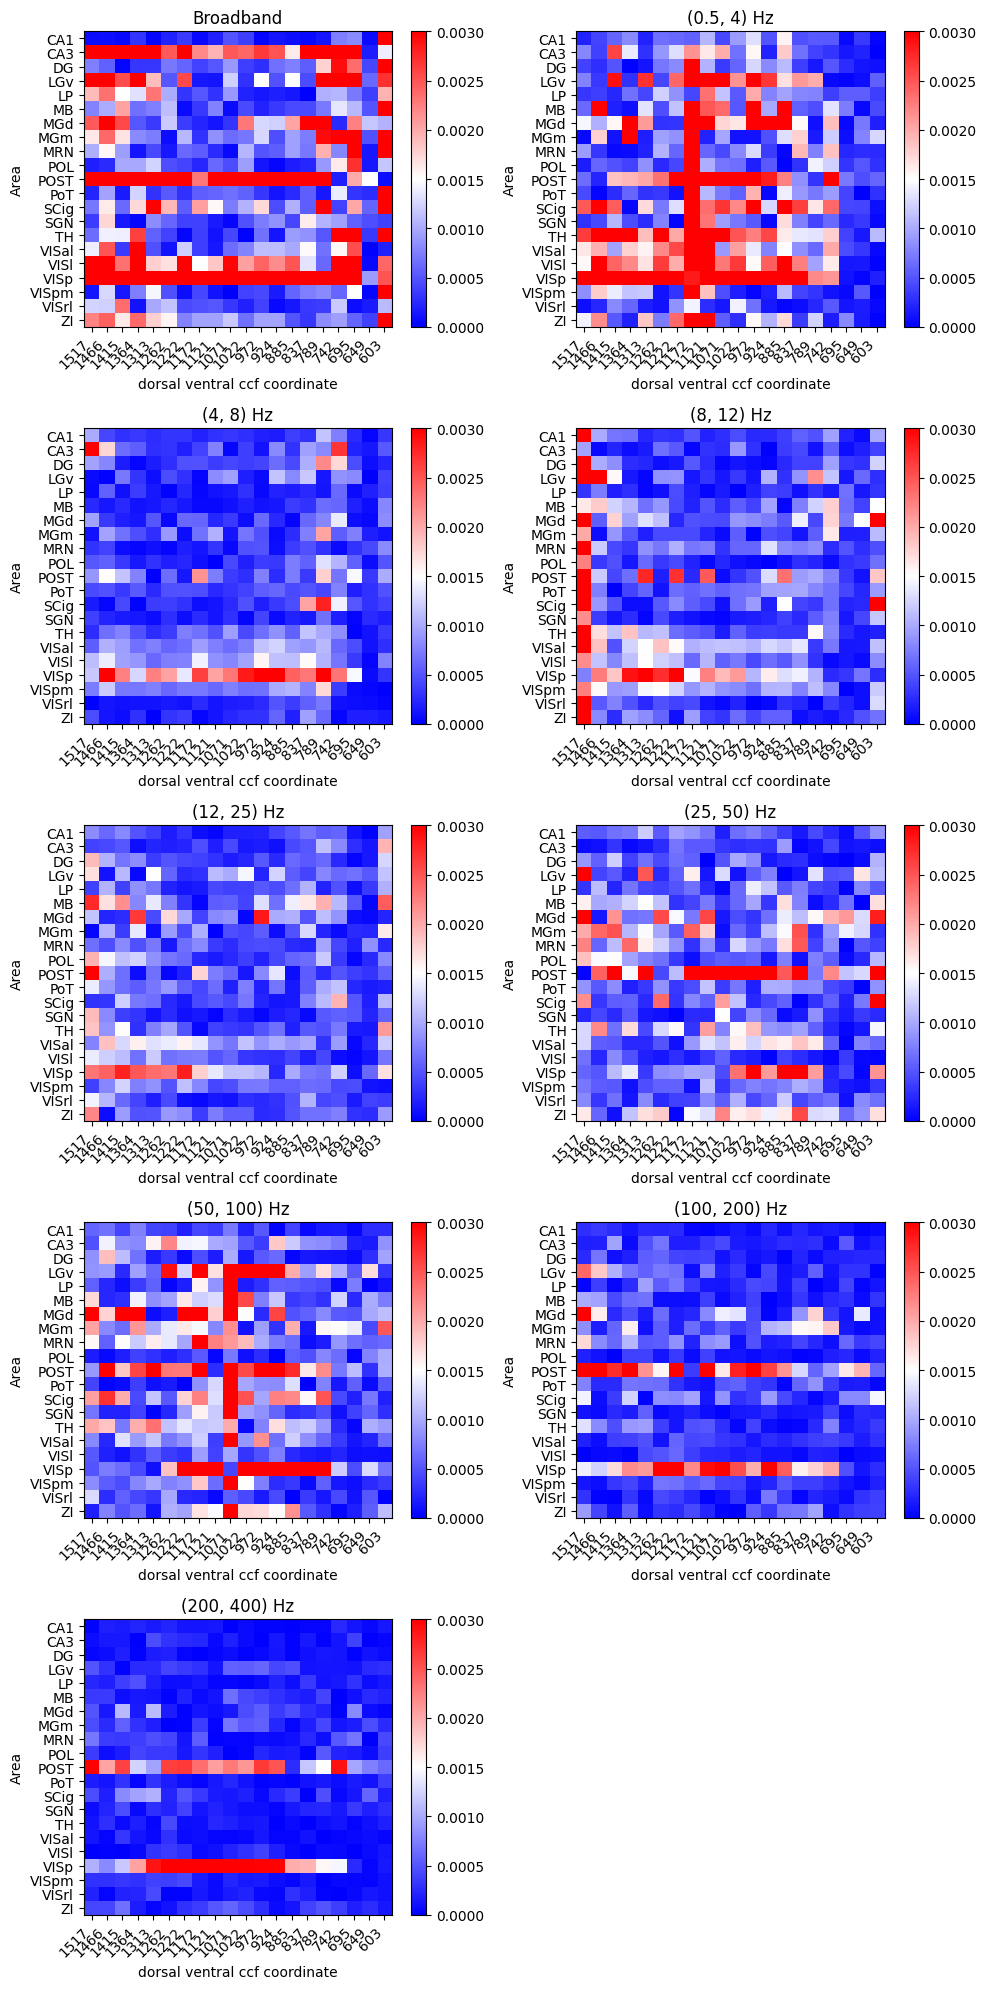

In [236]:
# for each band, plot the mean attribution for each area
fig, ax = plt.subplots(int(np.ceil((len(bands)+1)/2)),2,figsize=(10,20))
for bandi in range(len(bands)+1):
    ax.flat[bandi].imshow( np.abs(attributions_areas[:,bandi,:]) , aspect='auto', vmin=0, vmax=0.003, cmap='bwr')
    # set the xticks to be the channel depths
    ax.flat[bandi].set_xticks(range(num_channels))
    ax.flat[bandi].set_xticklabels(visp_df['dorsal_ventral_ccf_coordinate'].astype(int) , rotation=45, ha='right')
    ax.flat[bandi].set_xlabel('dorsal ventral ccf coordinate')

    # set the yticks to be the area names
    ax.flat[bandi].set_yticks(range(len(areas)))
    ax.flat[bandi].set_yticklabels(areas)
    ax.flat[bandi].set_ylabel('Area')
    if bandi == 0:
        ax.flat[bandi].set_title('Broadband')
    else:
        ax.flat[bandi].set_title(str(bands[bandi-1]) + ' Hz')
        
    cbar = fig.colorbar(ax.flat[bandi].imshow(np.abs(attributions_areas[:,bandi,:]), aspect='auto', vmin=0, vmax=0.003, cmap='bwr'), ax=ax.flat[bandi])

# tight layout
plt.tight_layout()
fig.delaxes(ax.flat[-1])

In [269]:
# get the mean attribution scores for each cluster_id across all channels and bands
units_df_merged = units.merge(df, how='left', left_on='id', right_index=True)

mean_attr_clusters = np.zeros((len(df['cluster_id'].unique()), len(bands)+1, num_channels))

for clusteri in range(1,6,1):
    for bandi in range(len(bands)+1):
        for chani in range(num_channels):
            ind = (units_df_merged['cluster_id_y'] == clusteri)
            mean_attr_clusters[clusteri, bandi, chani] = np.mean(attributions[chani, bandi, ind])

(0.0, 1.0, 0.0, 1.0)

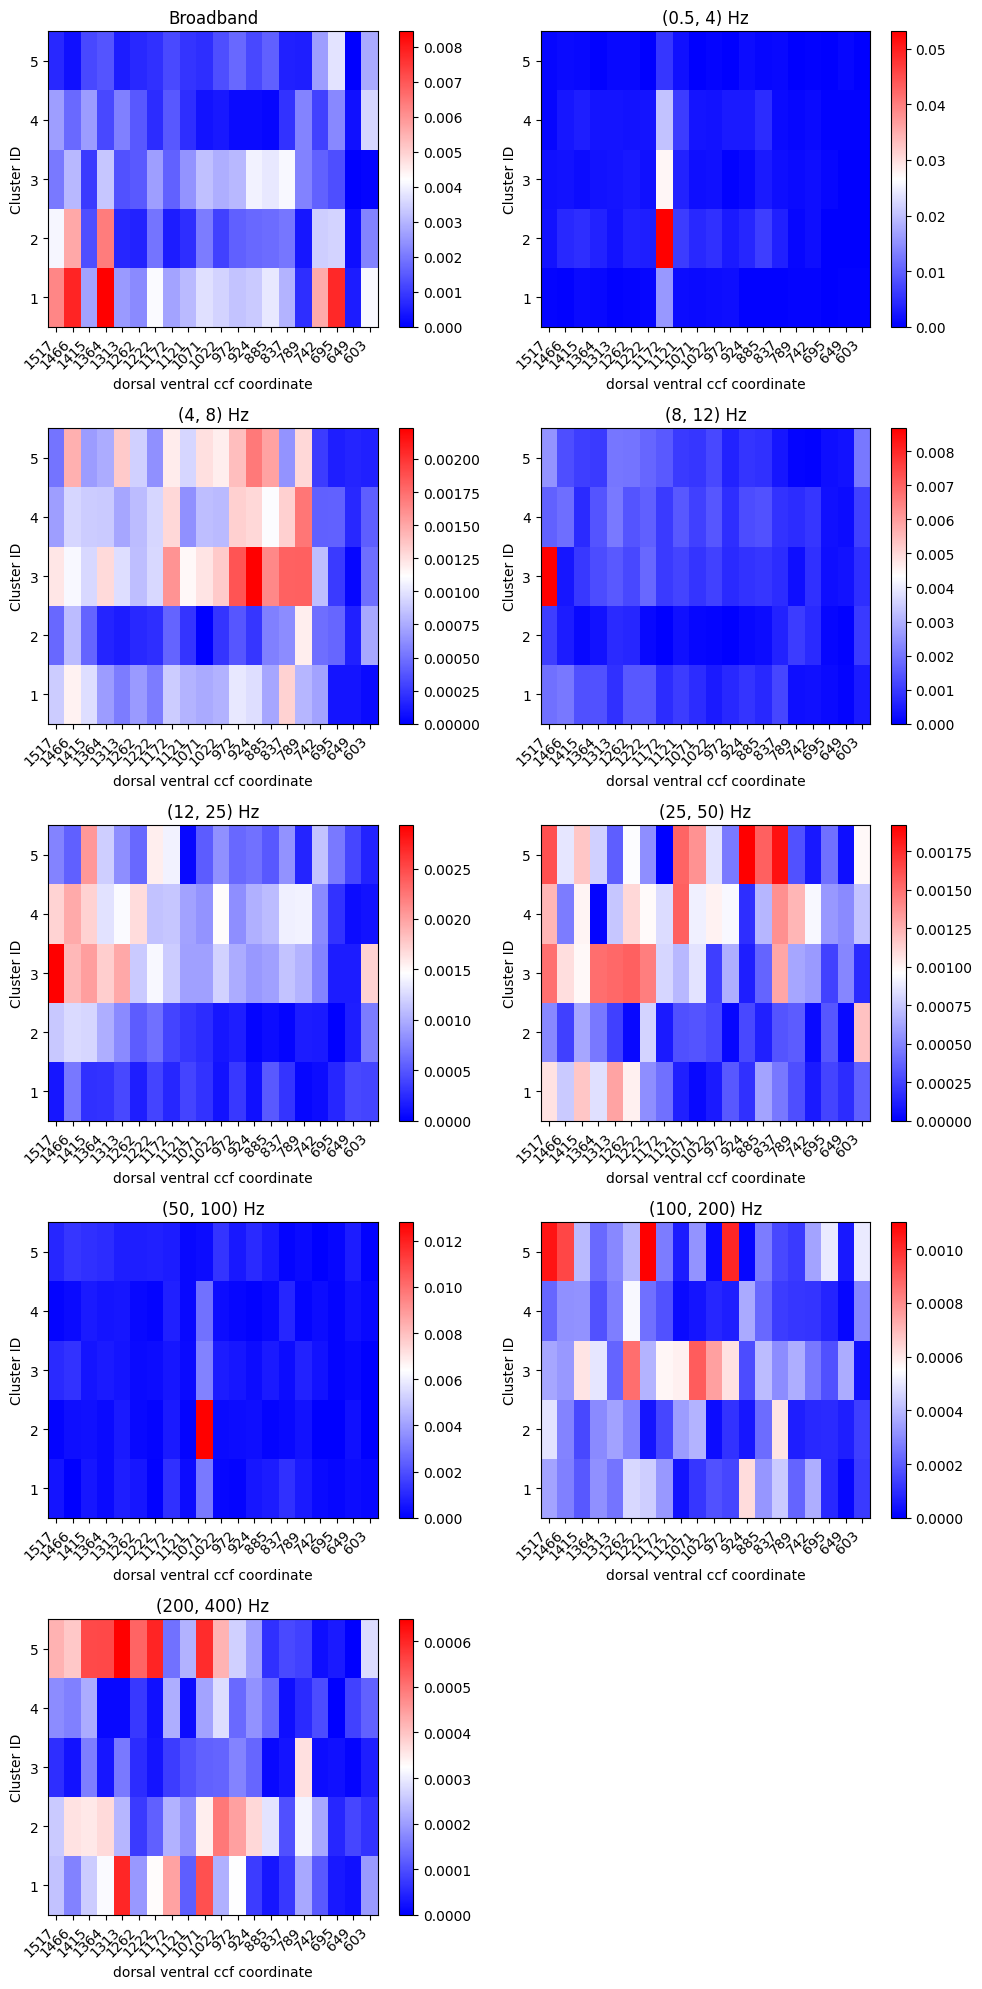

In [278]:
# plot the mean attribution for each band for each cluster and channel
fig, ax = plt.subplots(int(np.ceil((len(bands)+1)/2)),2,figsize=(10,20))

for bandi in range(len(bands)+1):
    ax.flat[bandi].imshow( np.abs(mean_attr_clusters[:,bandi,:]) , aspect='auto',cmap='bwr')
    # set the xticks to be the channel depths
    ax.flat[bandi].set_xticks(range(num_channels))
    ax.flat[bandi].set_xticklabels(visp_df['dorsal_ventral_ccf_coordinate'].astype(int) , rotation=45, ha='right')
    ax.flat[bandi].set_xlabel('dorsal ventral ccf coordinate')
    ax.flat[bandi].set_ylim([.5,5.5])
    if bandi == 0:
        ax.flat[bandi].set_title('Broadband')
    else:
        ax.flat[bandi].set_title(str(bands[bandi-1]) + ' Hz')
    # set the yticks to be the cluster ids
    ax.flat[bandi].set_yticks(range(1,6,1))
    ax.flat[bandi].set_yticklabels(range(1,6,1))
    ax.flat[bandi].set_ylabel('Cluster ID')
    cbar = fig.colorbar(ax.flat[bandi].imshow(np.abs(mean_attr_clusters[:,bandi,:]), aspect='auto', cmap='bwr'), ax=ax.flat[bandi])
    
# tight layout
plt.tight_layout()
ax.flat[-1].axis('off')